In [1]:
!pip -qq install evaluate

# Essentials
 - Imports
 - Seed

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments,
    TrainerCallback,
    EvalPrediction
)
import evaluate
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc

import random
import os
import re
import warnings

warnings.filterwarnings("ignore")

SEED = 42

def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
#         torch.cuda.manual_seed_all(seed)  # if you are using multi-GPU
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# Set the seed value
set_seed(SEED)

2024-06-28 21:51:32.959843: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-06-28 21:51:32.959968: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-06-28 21:51:33.103627: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Classed and functions
- Dataset class
- text_cleaner function for text preprocessing (not used here as encoded dsets are loaded for faster run time)
- other stuff like splits and dset creation
- compute_metrics for evaluation

In [3]:
class SpecialDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        # Convert encodings and labels to tensors if needed
        self.encodings = {key: val if torch.is_tensor(val) else torch.tensor(val) for key, val in encodings.items()}
        self.labels = labels if torch.is_tensor(labels) else torch.tensor(labels)

    def __getitem__(self, idx):
        # Get item by index
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

    def to(self, device):
        # Move encodings and labels to the specified device
        self.encodings = {key: val.to(device) for key, val in self.encodings.items()}
        self.labels = self.labels.to(device)
        return self  # Return self to allow chaining
    
    
def text_cleaner(text):
    # Lowercase the text
    text = text.lower()
    
    # Replace URLs with _url_
    text = re.sub(r'https?://\S+|www\.\S+', '_url_', text)
    
    # Replace emails with _email_
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', '_email_', text)
    
    # Remove special characters except ', ", _url_, and _email_
    text = re.sub(r"[^a-zA-Z0-9\s'\"_]", '', text)
    
    # Remove sequences of underscores that are not _url_ or _email_
    def clean_underscores(match):
        text = match.group(0)
        if text in ['_url_', '_email_']:
            return text
        return text.replace('_', '')

    text = re.sub(r'\b_[a-zA-Z0-9_]*_\b', clean_underscores, text)
    
    # Replace sequences of whitespace with a single space
    text = re.sub(r'\s+', ' ', text)
    
    # Strip leading and trailing whitespace
    text = text.strip()
    
    return text

def get_texts_labels():
    
    texts = []
    labels = []
    # Directory path
    directory_path = '/kaggle/input/phishing-email-dataset'
    
    # Iterate through the directory
    for filename in os.listdir(directory_path):
        if filename.endswith('.csv') and filename != 'phishing_email.csv':
            print(f'Processing: {filename}')
            file_path = os.path.join(directory_path, filename)

            # Read the CSV file
            df = pd.read_csv(file_path).dropna()
            texts += df.body.apply(text_cleaner).tolist()
            labels += df.label.tolist()
    return texts, labels

def split_data(texts: list[str], labels: list[str]):
    global SEED
    # Split into train (80%) and combined eval/test set (20%)
    train_texts, eval_test_texts, train_labels, eval_test_labels = train_test_split(
        texts, labels, test_size=0.2, random_state=SEED, stratify=labels)

    # Further split eval_test into eval (10%) and test (10%)
    eval_texts, test_texts, eval_labels, test_labels = train_test_split(
        eval_test_texts, eval_test_labels, test_size=0.5, random_state=SEED, stratify=eval_test_labels)
    return train_texts, eval_texts, test_texts, train_labels, eval_labels, test_labels


def encode_texts(texts: list[str],
                 tokenizer: BertTokenizer,
                 max_length: int = 512):
    encodings = tokenizer(texts, truncation=True, padding=True, max_length=max_length, return_tensors='pt')
    return encodings


def get_datasets(texts: list[str],
                 labels: list[str],
                 tokenizer_dir: str = '/kaggle/input/huggingface-bert/bert-base-uncased',
                 save: bool = False,
                 move: bool = False):
    global device
    
    tokenizer = BertTokenizer.from_pretrained(tokenizer_dir)

    train_texts, eval_texts, test_texts, train_labels, eval_labels, test_labels = split_data(texts, labels)

    train_encodings = encode_texts(train_texts, tokenizer)
    eval_encodings = encode_texts(eval_texts, tokenizer)
    test_encodings = encode_texts(test_texts, tokenizer)
    
    train_dset = SpecialDataset(train_encodings, train_labels)
    eval_dset = SpecialDataset(eval_encodings, eval_labels)
    test_dset = SpecialDataset(test_encodings, test_labels)
    
    if move:
        train_dset = train_dset.to(device)
        eval_dset = eval_dset.to(device)
        test_dset = test_dset.to(device)
    if save:
        tokenizer.save_pretrained('/kaggle/working/tokenizer_save')
    
    return train_dset, eval_dset, test_dset

# Load the metrics from the evaluate library
accuracy_metric = evaluate.load("accuracy")
roc_auc_metric = evaluate.load("roc_auc")

def compute_metrics(p: EvalPrediction):
    global accuracy_metric
    global roc_auc_metric
    preds = np.argmax(p.predictions, axis=1)  # Get predicted classes
    
    # Compute accuracy
    accuracy_result = accuracy_metric.compute(predictions=preds, references=p.label_ids)
    
    # Compute ROC AUC
    if p.predictions.shape[1] == 2:
        # For binary classification, use the probabilities of the positive class
        probs = p.predictions[:, 1]
        roc_auc_result = roc_auc_metric.compute(prediction_scores=probs, references=p.label_ids)
    else:
        # For multi-class classification, use the probabilities of each class
        roc_auc_result = roc_auc_metric.compute(prediction_scores=p.predictions, references=p.label_ids, multi_class='ovr')

    return {
        "accuracy": accuracy_result["accuracy"],
        "roc_auc": roc_auc_result["roc_auc"]
    }

## Load datasets
- One can uncomment original pre-processing
- One can load already tokenized dataset

In [4]:
# Load the fine-tuned model and tokenizer
model_path = '/kaggle/input/phishing-email-classifier-bert/transformers/scam-email-classifier-bert-uncased'
tokenizer_path = '/kaggle/input/phishing-email-classifier-bert/transformers/scam-email-bert-tokenizer'
dsets_dir = '/kaggle/input/phishing-email-classifier-bert/phishing-email-encoded-datasets'
model = BertForSequenceClassification.from_pretrained(model_path)
tokenizer = BertTokenizer.from_pretrained(tokenizer_path)

# IF CREATING FROM ORIGINAL DATASET
# texts, labels = get_texts_labels()
# print('Creating datasets')
# train_dset, eval_dset, test_dset = get_datasets(texts, labels, tokenizer_path)
# print('Datasets created')

# ELSE LOAD ENCODED DATASETS
train_dset = torch.load(os.path.join(dsets_dir, 'train.pth'))
eval_dset = torch.load(os.path.join(dsets_dir, 'validation.pth'))
test_dset = torch.load(os.path.join(dsets_dir, 'test.pth'))
print(f'Train size: {len(train_dset)}')
print(f'Validation size: {len(eval_dset)}')
print(f'Test size: {len(test_dset)}')

Train size: 63724
Validation size: 7966
Test size: 7966


## Use pre-trained and fine-tuned model
- load
- predict test set
- results

In [5]:
training_args = torch.load(os.path.join(model_path, 'training_args.bin'))

# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics
)

# Predict and evaluate
results = trainer.predict(test_dset)
metrics = results.metrics

print("Evaluation Metrics:", metrics)

Evaluation Metrics: {'test_loss': 0.04378143697977066, 'test_accuracy': 0.9919658548832538, 'test_roc_auc': 0.9993792817466137, 'test_runtime': 128.0963, 'test_samples_per_second': 62.188, 'test_steps_per_second': 3.888}


### ROC plot and some examples from test set

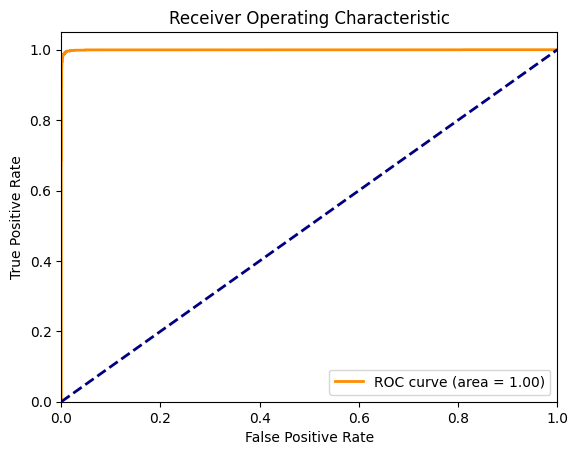

Email: sally shari mao contacted her boyfriend and he gave her the name of a larynx specialist at methodist hospital dr donald t donovan 713 798 5900 i hope this might be helpful lisa cousino
True Label: 0, Predicted Label: 0

Email: url _ url _ date 20021003t2215490800 the defective yeti isn't fond of culture jam i read it a year or so ago and joined adbusters as a result i liked the book but more importantly i liked the message it resonated with me a lot yes
True Label: 0, Predicted Label: 0

Email: apologies if you receive multiple copies of this email dear all for many years there has been a need for an email distribution list for machine learning research although " connectionists " " mllist " and " kdnuggets " have been useful each has had policies that limited their value to the broader machine learning community the imls _ url _ has therefore decided to create a new list known as " machine learning news " this will be an appropriate place to post announcements of jobs calls for

In [6]:
# Plot ROC AUC
if results.predictions.shape[1] == 2:
    probs = results.predictions[:, 1]
    fpr, tpr, _ = roc_curve(test_dset.labels, probs)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc='lower right')
    plt.show()

# Indices for true labels 0 and 1
true_label_0_indices = [i for i, label in enumerate(test_dset.labels) if label == 0]
true_label_1_indices = [i for i, label in enumerate(test_dset.labels) if label == 1]

# Randomly sample 5 indices from each
sample_indices_0 = random.sample(true_label_0_indices, 5)
sample_indices_1 = random.sample(true_label_1_indices, 5)

# Combine the samples
sample_indices = sample_indices_0 + sample_indices_1

# Print the emails with corresponding true and predicted labels
for idx in sample_indices:
    email_encoding = {key: val[idx].unsqueeze(0) for key, val in test_dset.encodings.items()}
    input_ids = email_encoding['input_ids']
    email_text = tokenizer.decode(input_ids[0], skip_special_tokens=True)
    true_label = test_dset.labels[idx].item()
    predicted_label = np.argmax(results.predictions[idx])

    print(f"Email: {email_text}")
    print(f"True Label: {true_label}, Predicted Label: {predicted_label}\n")